Po každej úlohe nasleduje zhrnutie, v ktorom je opísané, aké závery naša skupina dokázala vyvodiť na základe vykonaných krokov.

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import math
from scipy.stats import boxcox, mannwhitneyu
import scipy.stats as stats
import statistics
import matplotlib.pyplot as plt

In [4]:
observation = pd.read_csv('../observation.csv', delimiter='\t')
patient = pd.read_csv('../patient.csv', delimiter='\t')
station = pd.read_csv('../station.csv', delimiter='\t')
patient = patient.drop("residence", axis=1)
patient = patient.drop('birthdate', axis=1)
patient = patient.drop("job", axis=1)
merged = pd.merge(
    patient, 
    station, 
    left_on='station_ID',
    right_index=True
)

Stĺpec bol odstránený, podrobné informácie sú uvedené v časti B-1b.

In [5]:
observation.head()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.240653,81.353362,7.150900,16.455165,40.139514,58.088019,130.517598,106.734767,34.575495,6.744899,...,4.109261,61.972714,31.751870,53.023017,54.786281,0.264564,32.364555,0.0,51.84819,1.26738
1,98.296387,69.297622,9.748389,18.179820,40.202706,59.981954,92.571343,94.833525,34.402921,12.358720,...,4.011034,53.873430,53.549948,59.871862,44.600096,0.298243,21.470525,1.0,19.32932,-98.16640
2,97.561590,84.103847,12.457043,14.090045,40.163760,57.037165,82.981147,109.770957,36.362083,13.112131,...,4.196129,44.945105,68.897858,64.007301,31.875287,0.208295,35.141216,1.0,34.21639,-119.03760
3,97.956431,69.736747,10.159555,16.073192,38.367245,60.461869,113.123181,103.350282,35.164909,5.395552,...,4.018147,25.615688,37.049185,55.797946,54.223522,0.219717,22.754344,0.0,43.61058,1.33467
4,98.641145,83.580193,12.462217,13.957125,40.933822,54.375525,122.740320,104.684783,33.884270,3.844221,...,4.183259,21.927280,58.039403,48.895308,55.838077,0.296221,27.145677,0.0,11.85000,38.01667


In [6]:
patient.head()

,user_id,current_location,username,company,registration,mail,name,ssn,blood_group,station_ID
0,1544,"(Decimal('-67.5402955'), Decimal('-114.522482'))",ucolletti,Corcos SPA,25 May 2025,francesco60@gmail.com,Giorgia Sauro,SRNFST50B52F775U,O+,428
1,4,"(Decimal('24.680131'), Decimal('32.809946'))",sayurikobayashi,株式会社藤井建設,07 Jul 2025,vmiura@hotmail.com,佐々木 学,481-65-6983,O-,451
2,1501,"(Decimal('-51.1234865'), Decimal('130.651957'))",nbenthin,Rogner Wilms GmbH & Co. KG,"10/25/2021, 00:00:00",ajungfer@gmx.de,Evelin Fischer,566-56-2746,O-,204
3,653,"(Decimal('-60.9439985'), Decimal('157.720074'))",ndias,Ferreira,09 Jun 2020,maria-luisacarvalho@uol.com.br,Davi Lucca Guerra,65940318215,B-,82
4,1116,"(Decimal('46.6915195'), Decimal('-51.672004'))",montesanolivio,Andreozzi s.r.l.,2023/07/23,lucianapacomio@tiscali.it,Venancio Morgagni,CNTSMN15B57G939D,O+,173


In [7]:
station.head()

,code,latitude,location,longitude,station,revision
0,US,40.93121,America/New_York,-73.89875,Yonkers,2021/01/24
1,IN,27.92470,Asia/Kolkata,78.40102,Chharra,2022/03/25
2,US,33.03699,America/Los_Angeles,-117.29198,Encinitas,"07/02/2023, 00:00:00"
3,FR,48.98994,Europe/Paris,2.16990,Herblay,"08/24/2018, 00:00:00"
4,DE,50.72043,Europe/Berlin,11.34046,Rudolstadt,2023-01-28


In [8]:
observation.shape

(12022, 23)

In [9]:
patient.shape

(2044, 10)

In [10]:
station.shape

(856, 6)

In [11]:
observation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12022 entries, 0 to 12021
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12022 non-null  float64
 1   HR                     12022 non-null  float64
 2   PI                     12022 non-null  float64
 3   RR                     12022 non-null  float64
 4   EtCO₂                  12022 non-null  float64
 5   FiO₂                   12022 non-null  float64
 6   PRV                    12022 non-null  float64
 7   BP                     12022 non-null  float64
 8   Skin Temperature       12022 non-null  float64
 9   Motion/Activity index  12022 non-null  float64
 10  PVI                    12022 non-null  float64
 11  Hb level               12022 non-null  float64
 12  SV                     12022 non-null  float64
 13  CO                     12022 non-null  float64
 14  Blood Flow Index       12022 non-null  float64
 15  PP

In [12]:
patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2044 entries, 0 to 2043
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_id           2044 non-null   int64 
 1   current_location  1942 non-null   object
 2   username          2044 non-null   object
 3   company           2044 non-null   object
 4   registration      2044 non-null   object
 5   mail              2044 non-null   object
 6   name              2044 non-null   object
 7   ssn               2044 non-null   object
 8   blood_group       2044 non-null   object
 9   station_ID        2044 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 159.8+ KB


In [13]:
station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   code       856 non-null    object 
 1   latitude   856 non-null    float64
 2   location   856 non-null    object 
 3   longitude  856 non-null    float64
 4   station    856 non-null    object 
 5   revision   856 non-null    object 
dtypes: float64(2), object(4)
memory usage: 40.3+ KB


# A-1b

Dáta sme mali uložené vo formáte **CSV**, ktorý sme načítali do prostredia Python pomocou knižnice pandas ako DataFrame. Dataset Observation obsahuje 12 022 riadkov a 23 stĺpcov, pričom zaznamenáva merania rôznych fyziologických parametrov pacientov (vsetky data su float64). Dataset Patient má 2 044 riadkov a 11 stĺpcov a obsahuje základné informácie o pacientoch, ako blood group, meno či ine údaje. Dataset Station má 856 riadkov a 6 stĺpcov. Každý dataset má dobre definovanú štruktúru.

In [12]:
observation.describe()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,...,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000,12022.000000
mean,97.612862,80.687149,9.180268,16.342317,40.090329,59.414828,106.602260,104.550611,35.694128,9.731759,...,4.165612,45.165750,48.463326,53.154081,49.478761,0.249502,29.976833,0.595325,28.733944,10.275859
std,0.697656,5.157388,2.372628,0.969665,1.257749,10.810266,24.538449,3.716866,0.924738,3.104441,...,0.205145,12.709840,12.606927,13.383947,13.846784,0.028928,5.758020,0.490849,24.035512,74.548317
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,0.924405,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-44.396720,-156.474320
25%,97.113396,77.271022,7.591189,15.696061,39.244287,52.172970,90.115714,102.051752,34.929047,7.395671,...,4.057830,36.563536,39.973527,44.158125,39.937886,0.224488,24.978078,0.000000,14.537670,-60.183100
50%,97.660583,80.691323,9.169076,16.342201,40.068287,59.445967,106.294352,104.548336,35.859879,9.681788,...,4.104875,44.911991,48.335429,53.284007,49.486977,0.248999,30.041891,1.000000,36.063860,10.700000
75%,98.118804,84.143183,10.775421,16.982630,40.909909,66.643100,123.239900,107.058445,36.462289,12.342498,...,4.195550,53.716437,57.022272,62.167158,58.850744,0.274651,34.946009,1.000000,47.805270,70.911060
max,100.000000,100.000000,20.000000,20.000000,45.000000,100.000000,200.000000,120.000000,38.000000,18.152173,...,8.000000,100.000000,100.000000,100.000000,100.000000,0.300000,40.000000,1.000000,68.798330,178.004170


In [13]:
patient.describe()

,user_id,station_ID
count,2044.000000,2044.000000
mean,1022.497554,437.616438
std,584.439360,246.382361
min,0.000000,0.000000
25%,547.000000,225.000000
50%,1007.000000,448.000000
75%,1521.500000,645.250000
max,2043.000000,855.000000


In [14]:
station.describe()

,latitude,longitude
count,856.000000,856.000000
mean,28.709774,10.322992
std,24.066163,74.591525
min,-44.396720,-156.474320
25%,14.496740,-60.183100
50%,36.031930,10.700000
75%,47.805270,71.009878
max,68.798330,178.004170


In [15]:
observation.nunique()

SpO₂                     11844
HR                       11844
PI                       11844
RR                       11844
EtCO₂                    11844
FiO₂                     11844
PRV                      11844
BP                       11844
Skin Temperature         11844
Motion/Activity index    11844
PVI                      11844
Hb level                 11844
SV                       11844
CO                       11844
Blood Flow Index         11844
PPG waveform features    11844
Signal Quality Index     11844
Respiratory effort       11844
O₂ extraction ratio      11844
SNR                      11844
oximetry                     2
latitude                   556
longitude                  556
dtype: int64

In [16]:
patient.nunique()
a=0

In [17]:
station.nunique()

code         105
latitude     556
location     145
longitude    556
station      556
revision     834
dtype: int64

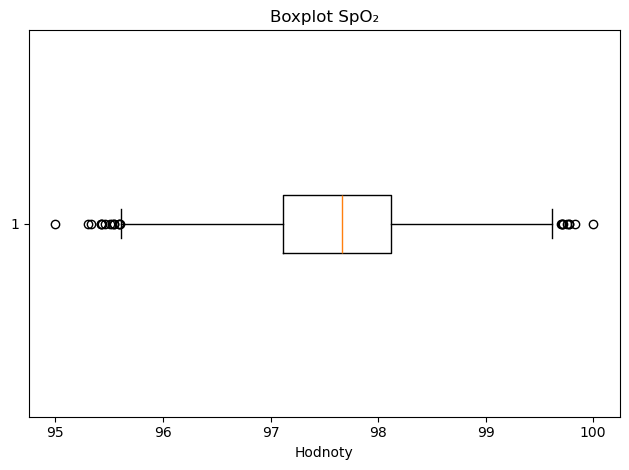

In [18]:

plt.boxplot(observation["SpO₂"], vert=False)
plt.title("Boxplot SpO₂")
plt.xlabel("Hodnoty")

plt.tight_layout()
plt.show()


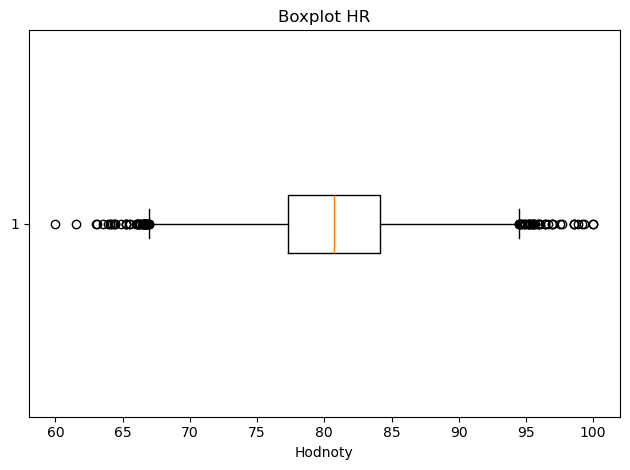

In [19]:
plt.boxplot(observation["HR"], vert=False)
plt.title("Boxplot HR")
plt.xlabel("Hodnoty")

plt.tight_layout()
plt.show()


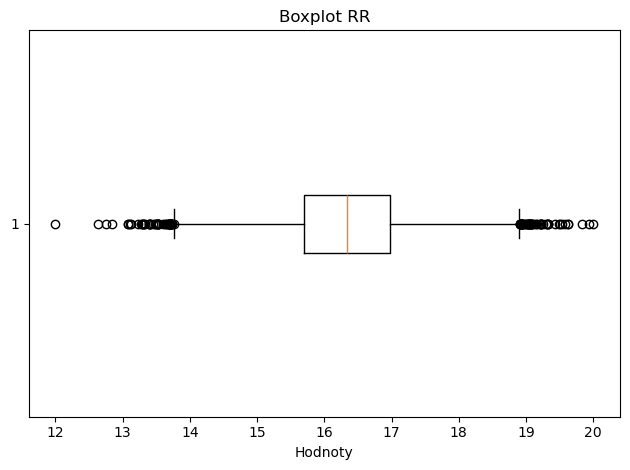

In [20]:

plt.boxplot(observation["RR"], vert=False)
plt.title("Boxplot RR")
plt.xlabel("Hodnoty")

plt.tight_layout()
plt.show()


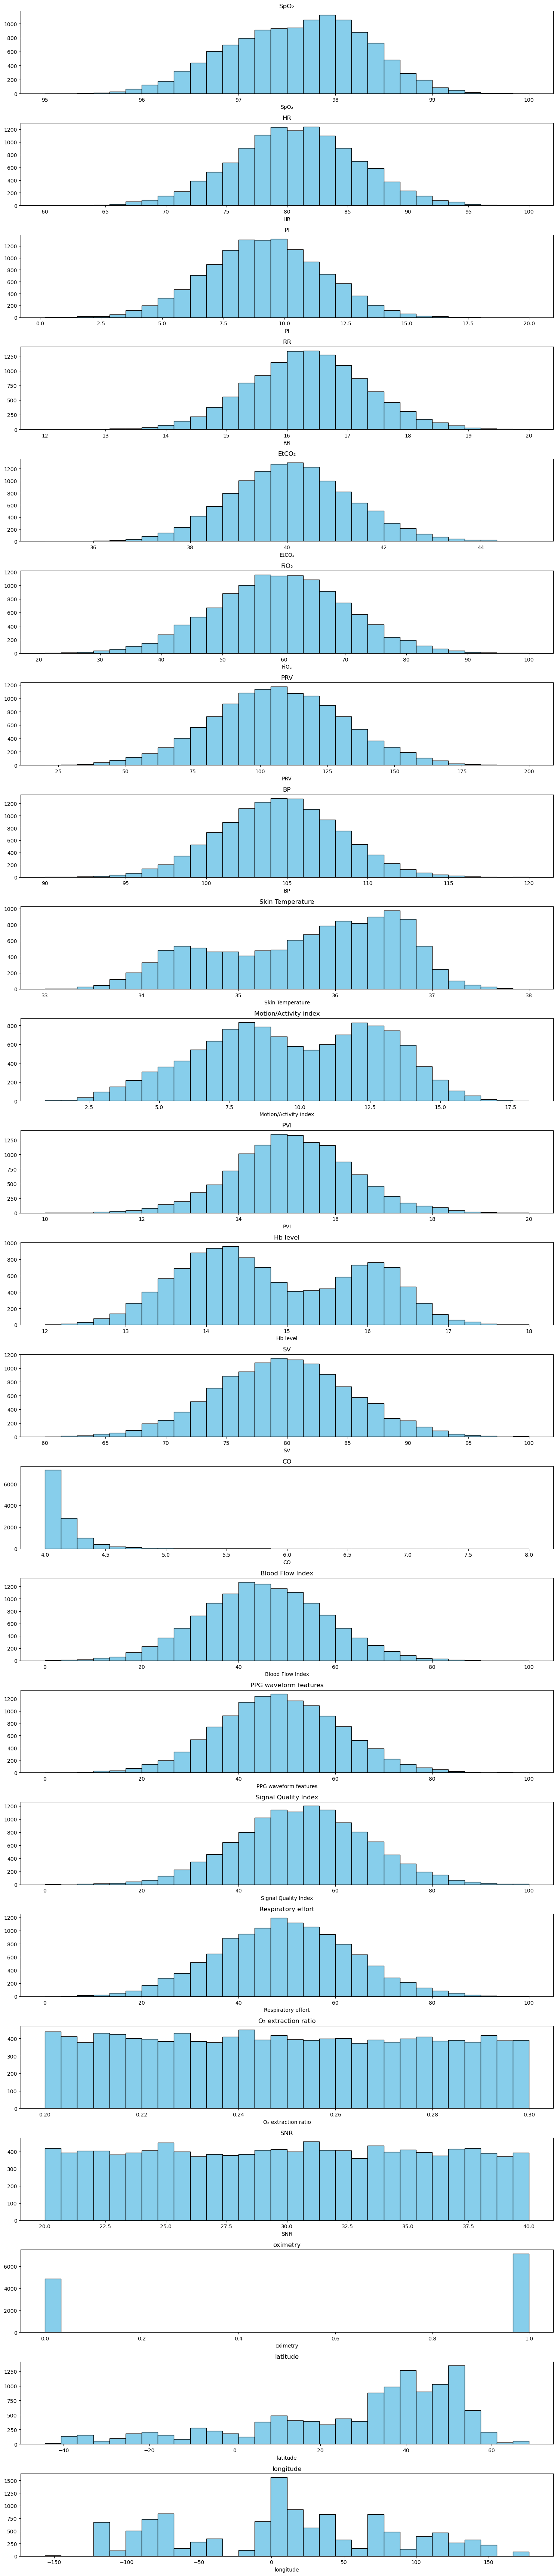

In [21]:
cols = observation.columns

plt.figure(figsize=(15, len(cols) * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.hist(observation[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.show()

# B-1b

Viacero údajov sú približne normálne rozložené, čo môžeme vidieť z histogramov. Z boxplotov je zároveň zrejmé, že niektoré atribúty obsahujú odľahlé hodnoty (outliery). Pomocou funkcie describe() sme získali prehľad o minimálnych, maximálnych a inych hodnotách. Zo súboru Patient sme odstránili stĺpec **residence**, pretože neobsahoval žiadne údaje a neposkytoval žiadnu **užitočnú** informáciu. Stlpec birthday obsahoval vela NaN hodnot a udaje ktore obsahoval boli ne spracovatelne. **Dáta sú tak pripravené na ďalšiu analýzu a spracovanie.** Vsetky data su normalne a pravdive.

In [22]:
corr = np.corrcoef(observation["SpO₂"],observation["HR"])[0,1]
corr

np.float64(0.009959477211986907)

In [23]:
df = observation[["SpO₂","HR"]].dropna()
corr = np.corrcoef(df["SpO₂"], df["HR"])[0,1]
corr

np.float64(0.009959477211986907)

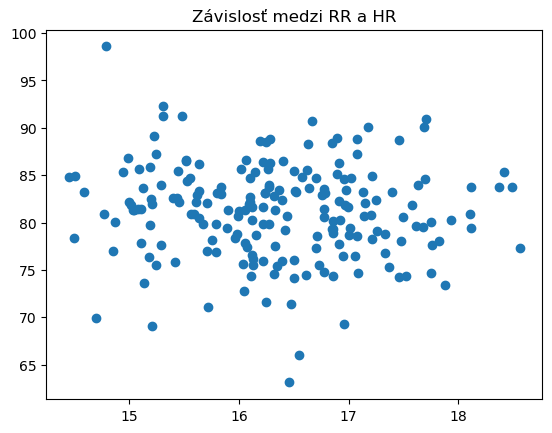

In [24]:
sample_200 = observation.sample(n=200, random_state=42)


plt.scatter(sample_200["RR"], sample_200["HR"])

plt.title("Závislosť medzi RR a HR")
plt.show()

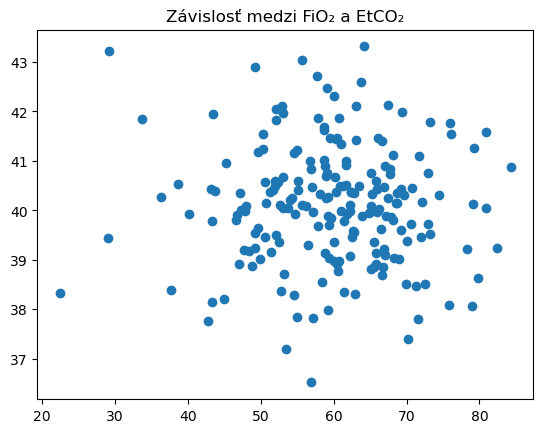

In [25]:
plt.scatter(sample_200["FiO₂"], sample_200["EtCO₂"])
plt.title("Závislosť medzi FiO₂ a EtCO₂")
plt.show()

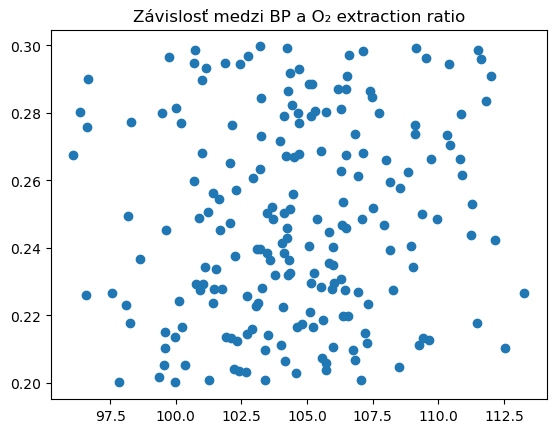

In [26]:
plt.scatter(sample_200["BP"], sample_200["O₂ extraction ratio"])
plt.title("Závislosť medzi BP a O₂ extraction ratio")
plt.show()

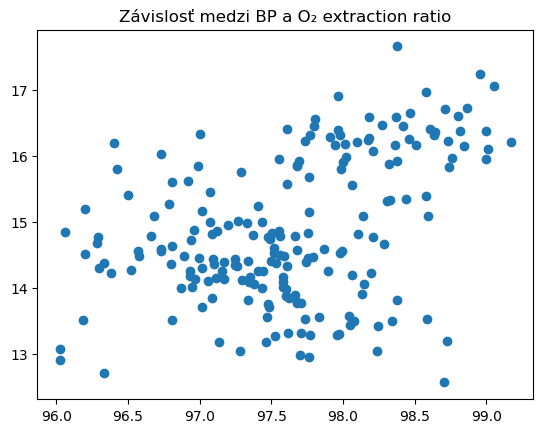

In [27]:
plt.scatter(sample_200["SpO₂"], sample_200["Hb level"])
plt.title("Závislosť medzi BP a O₂ extraction ratio")
plt.show()

In [28]:
cols = observation.columns

correlations = []

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1, col2 = cols[i], cols[j]
        corr_value = np.corrcoef(observation[col1], observation[col2])[0, 1]
        correlations.append((col1, col2, corr_value))

corr_df = pd.DataFrame(correlations, columns=["Feature 1", "Feature 2", "Correlation"])

corr_df = corr_df.sort_values(by="Correlation", ascending=False)

print("Top 20 najsilnejších korelácií:")
print(corr_df.head(10))
print(corr_df.tail(10))

Top 20 najsilnejších korelácií:
                 Feature 1              Feature 2  Correlation
33                      HR                     CO     0.763208
172  Motion/Activity index               oximetry     0.663803
159       Skin Temperature               oximetry     0.364418
10                    SpO₂               Hb level     0.356698
148       Skin Temperature  Motion/Activity index     0.317691
8                     SpO₂  Motion/Activity index     0.310744
19                    SpO₂               oximetry     0.286030
3                     SpO₂                  EtCO₂     0.101878
88                   EtCO₂               Hb level     0.095516
162  Motion/Activity index                    PVI     0.084987
                 Feature 1              Feature 2  Correlation
147                     BP              longitude    -0.033965
163  Motion/Activity index               Hb level    -0.042602
149       Skin Temperature                    PVI    -0.073952
7                     S

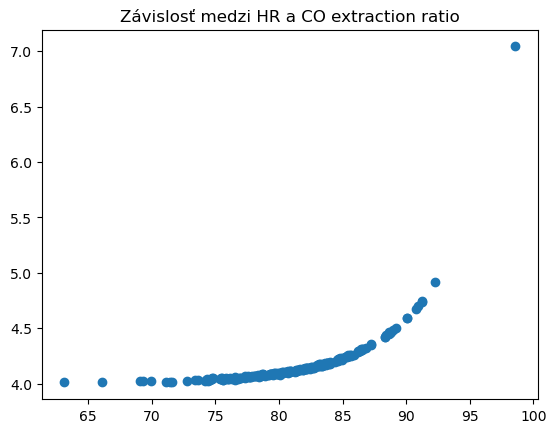

In [29]:
plt.scatter(sample_200["HR"], sample_200["CO"])
plt.title("Závislosť medzi HR a CO extraction ratio")
plt.show()

In [30]:
from scipy.stats import pointbiserialr
r, p = pointbiserialr(observation["oximetry"], observation["Motion/Activity index"])
print(f"r={r}, p={p}")

r=0.6638033535511547, p=0.0


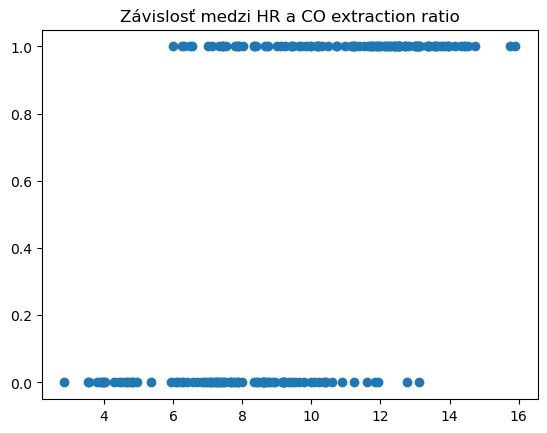

In [31]:
plt.scatter(sample_200["Motion/Activity index"], sample_200["oximetry"])
plt.title("Závislosť medzi HR a CO extraction ratio")
plt.show()

# C-1b  D-1b

Po analýze údajov som dospel k záveru, že index pohybu (Motion/Activity Index) a teplota kože sú dôležité ukazovatele, pretože podľa štatistických údajov sú oba spojené s výsledkom — či je človek chorý alebo nie.

Motion/Activity Index a choroba: cor = 0.6638

Teplota kože a choroba: cor = 0.3644

Tiež som zistil inverznú závislosť medzi teplotou kože a hladinou hemoglobínu v krvi (cor = -0.4901). Tento výsledok môže byť užitočný, pretože teplota kože slabo, ale predsa len koreluje s ukazovateľmi okximetra a odráža možné fyziologické zmeny pri poruchách výmeny plynov.

Osobitne treba zdôrazniť, že úroveň kyslíka v krvi (SpO₂) má významnú koreláciu so zdravotným stavom človeka, čo potvrdzuje klinický význam tohto parametra.

Nakoniec bola zistená silná súvislosť medzi srdcovou frekvenciou (HR) a objemom krvi, ktorý srdce prečerpá (CO) — cor = 0.7632, čo je úplne logický fyziologický výsledok, pretože zvýšenie srdcovej frekvencie vedie k rastu srdcového výdaja.

# E-1b

Na záver prvého modulu chcem povedať, že som sa úplne oboznámil so znameniami dát, s ktorými pracujeme. Máme plné pochopenie veľkostí, formátov a hodnôt dát, ktoré máme k dispozícii. V tomto module sme sa hlavne detailne venovali analýze hlavného datasetu, z ktorého sme vyvodili množstvo užitočných záverov, ktoré nám môžu v budúcnosti pomôcť pri modelovaní systému na predikciu, či je človek chorý alebo nie.

Podľa nášho názoru je veľmi dobré, že máme široké spektrum poskytnutých informácií, s ktorými môžeme pracovať. Pomôže nám to presnejšie hodnotiť a robiť správne závery. Domnievame sa, že v budúcnosti budú také ukazovatele ako Motion/Activity Index, Skin Temperature, SpO₂ a Hb level dôležité, pretože tieto dáta priamo alebo nepriamo súvisia so vznikom choroby.

Tiež sme sa presvedčili, že dáta sú normálne a správne. Odstránili sme jeden nepotrebný stĺpec, s ostatnými dátami nie sú žiadne problémy a sme pripravení s nimi ďalej pracovať.

Skúšali sme aj smerdžovať ďalšie dve databázy, ale dospeli sme k záveru, že to nie je potrebné, pretože tieto dáta pre nás neobsahujú užitočné informácie. Pozerali sme sa aj na koeficienty korelácie a nič by sa podstatne nezmenilo. Naše stanovisko je, že táto informácia by nám nepriniesla hodnotu a iba by pridala množstvo NaN hodnôt — napríklad pri našich 12-tisíc záznamoch by vzniklo až 8–11 tisíc NaN. Preto sme sa rozhodli tieto databázy do analýzy nezahrnúť.

# 1.2

# A-2b

In [32]:
print(observation.duplicated().sum())

0


In [33]:
print(patient.duplicated().sum())

0


In [34]:
print(station.duplicated().sum())

0


In [35]:
print(observation.isna().sum())

SpO₂                     0
HR                       0
PI                       0
RR                       0
EtCO₂                    0
FiO₂                     0
PRV                      0
BP                       0
Skin Temperature         0
Motion/Activity index    0
PVI                      0
Hb level                 0
SV                       0
CO                       0
Blood Flow Index         0
PPG waveform features    0
Signal Quality Index     0
Respiratory effort       0
O₂ extraction ratio      0
SNR                      0
oximetry                 0
latitude                 0
longitude                0
dtype: int64


In [36]:
print(patient.isna().sum())

user_id               0
current_location    102
username              0
company               0
registration          0
mail                  0
name                  0
ssn                   0
blood_group           0
station_ID            0
dtype: int64


remooved job and residence

In [37]:
print(station.isna().sum())

code         0
latitude     0
location     0
longitude    0
station      0
revision     0
dtype: int64


In [38]:
patient['user_id'] = patient['user_id'].astype('int64')
patient['station_ID'] = patient['station_ID'].astype('int64')
patient['blood_group'] = patient['blood_group'].astype('category')
cols = ['username', 'company', 'job', 'mail', 'name', 'ssn']
for col in cols:
        if col in patient.columns:
            patient[col] = patient[col].astype('string')

In [39]:
station['code'] = station['code'].astype('string')
station['station'] = station['station'].astype('string')
station['location'] = station['location'].astype('string')

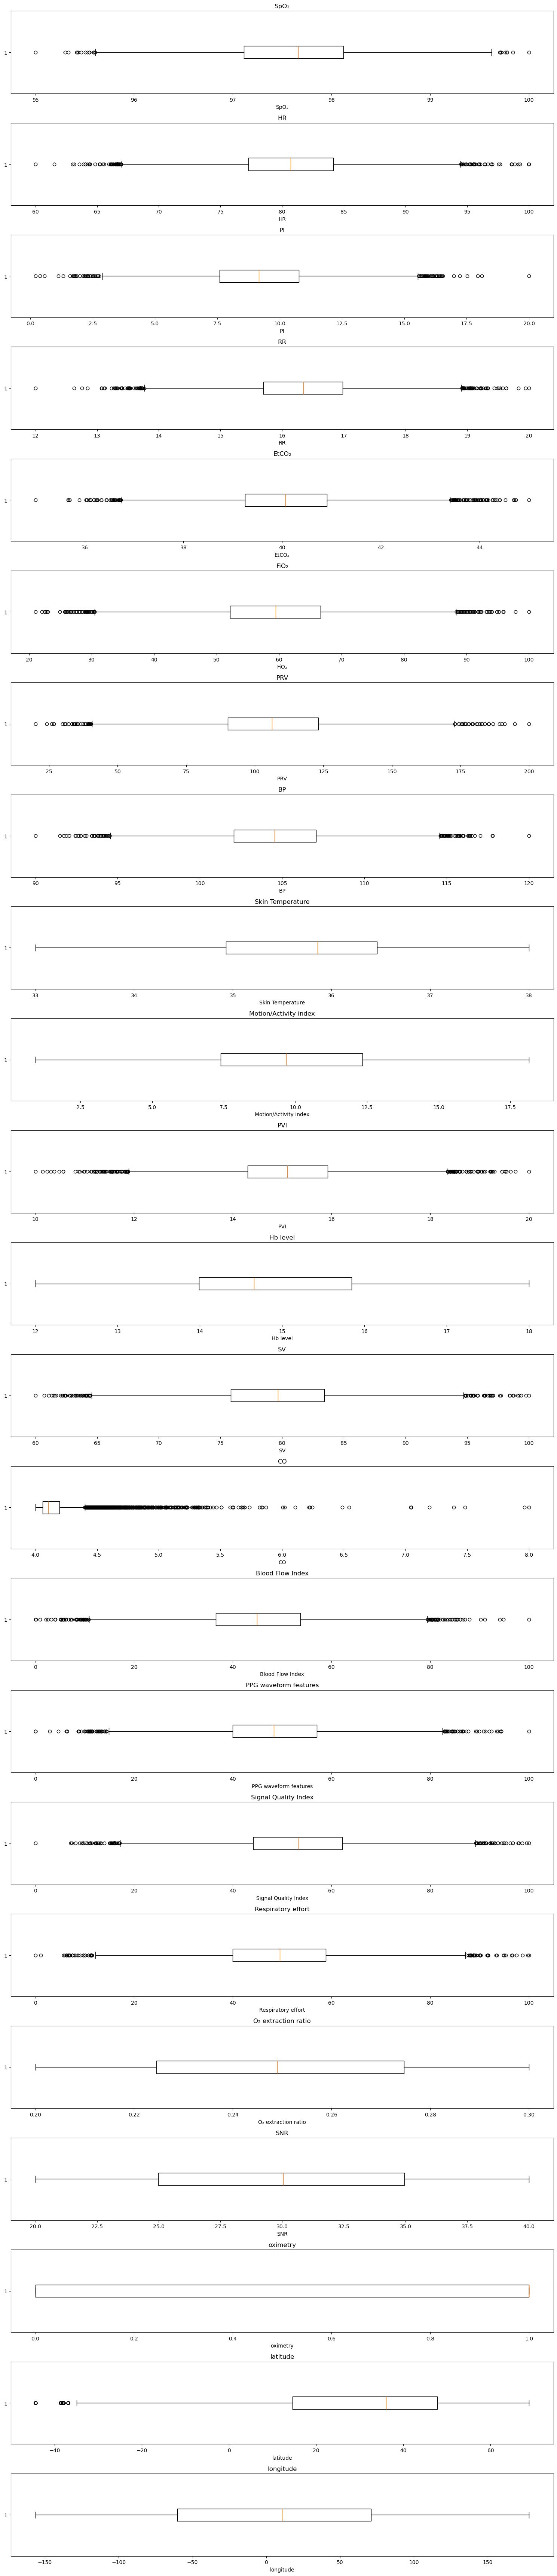

In [40]:
cols = observation.columns

plt.figure(figsize=(15, len(cols) * 3))

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    plt.boxplot(observation[col].dropna(), vert=False)
    plt.title(col)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


In [41]:
Q1_bfi = observation['Blood Flow Index'].quantile(0.25)
Q3_bfi = observation['Blood Flow Index'].quantile(0.75)
IQR_bfi = Q3_bfi - Q1_bfi
lower_bfi = Q1_bfi - 1.5 * IQR_bfi
upper_bfi = Q3_bfi + 1.5 * IQR_bfi
outliers_bfi = (observation['Blood Flow Index'] < lower_bfi) | (observation['Blood Flow Index'] > upper_bfi)
outliers_bfi.sum()

Q1_ppg = observation['PPG waveform features'].quantile(0.25)
Q3_ppg = observation['PPG waveform features'].quantile(0.75)
IQR_ppg = Q3_ppg - Q1_ppg
lower_ppg = Q1_ppg - 1.5 * IQR_ppg
upper_ppg = Q3_ppg + 1.5 * IQR_ppg
outliers_ppg = (observation['PPG waveform features'] < lower_ppg) | (observation['PPG waveform features'] > upper_ppg)
outliers_ppg.sum()

Q1_sqi = observation['Signal Quality Index'].quantile(0.25)
Q3_sqi = observation['Signal Quality Index'].quantile(0.75)
IQR_sqi = Q3_sqi - Q1_sqi
lower_sqi = Q1_sqi - 1.5 * IQR_sqi
upper_sqi = Q3_sqi + 1.5 * IQR_sqi
outliers_sqi = (observation['Signal Quality Index'] < lower_sqi) | (observation['Signal Quality Index'] > upper_sqi)
outliers_sqi.sum()


Q1_resp = observation['Respiratory effort'].quantile(0.25)
Q3_resp = observation['Respiratory effort'].quantile(0.75)
IQR_resp = Q3_resp - Q1_resp
lower_resp = Q1_resp - 1.5 * IQR_resp
upper_resp = Q3_resp + 1.5 * IQR_resp
outliers_resp = (observation['Respiratory effort'] < lower_resp) | (observation['Respiratory effort'] > upper_resp)
outliers_resp.sum()

observation = observation[
    ~(
        outliers_bfi |
        outliers_ppg |
        outliers_sqi |
        outliers_resp
    )
]
observation.shape

(11689, 23)

Dátové typy v dátových rámcoch sme upravili na správne formáty, skontrolovali ich na prítomnosť duplikátov a odstránili prázdne alebo nepotrebné stĺpce (NaN).

Rozhodli sme sa neodstraňovať odľahlé hodnoty (outliery) vo všetkých stĺpcoch, pretože na základe vizuálnej analýzy (boxplot) údaje pôsobia realisticky a neobsahujú zjavné chyby.

Napriek tomu sme sa v niektorých stĺpcoch rozhodli odstrániť odľahlé hodnoty, konkrétne v týchto:
outliers_bfi, outliers_ppg, outliers_sqi, outliers_resp.

Odstraňovanie odľahlých hodnôt je potrebné iba v prípadoch, keď predstavujú chyby v dátach (napr. teplota 200 °C, vek −5 rokov, pulz 10000), skresľujú štatistiku alebo zhoršujú učenie modelov citlivých na mierku.

V našom prípade sa žiadna z týchto situácií nevyskytuje, preto ostatné údaje zostali zachované.

# B-2b

Ako už bolo spomenuté v bodoch A-2b, C-1b a D-1b, údaje vyzerajú korektne a vierohodne: väčšina stĺpcov s chýbajúcimi hodnotami (NaN) bola odstránená. V údajoch sa nenachádzajú abnormálne ani nelogické hodnoty. Vzťahy medzi jednotlivými znakmi sú logické a zodpovedajú očakávaným závislostiam — napríklad, ako bolo uvedené v bode C-1b, pozoruje sa jasná súvislosť medzi počtom srdcových tepov a objemom cirkulujúcej krvi, čo potvrdzuje korelačný koeficient 0.7.

# C-1b

In [42]:
Q1 = observation["PVI"].quantile(0.25)
Q3 = observation["PVI"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data_no_outliers_PVI = observation[(observation["PVI"] >= lower_bound) & (observation["PVI"] <= upper_bound)]
data_no_outliers_PVI

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,97.240653,81.353362,7.150900,16.455165,40.139514,58.088019,130.517598,106.734767,34.575495,6.744899,...,4.109261,61.972714,31.751870,53.023017,54.786281,0.264564,32.364555,0.0,51.84819,1.26738
1,98.296387,69.297622,9.748389,18.179820,40.202706,59.981954,92.571343,94.833525,34.402921,12.358720,...,4.011034,53.873430,53.549948,59.871862,44.600096,0.298243,21.470525,1.0,19.32932,-98.16640
2,97.561590,84.103847,12.457043,14.090045,40.163760,57.037165,82.981147,109.770957,36.362083,13.112131,...,4.196129,44.945105,68.897858,64.007301,31.875287,0.208295,35.141216,1.0,34.21639,-119.03760
3,97.956431,69.736747,10.159555,16.073192,38.367245,60.461869,113.123181,103.350282,35.164909,5.395552,...,4.018147,25.615688,37.049185,55.797946,54.223522,0.219717,22.754344,0.0,43.61058,1.33467
4,98.641145,83.580193,12.462217,13.957125,40.933822,54.375525,122.740320,104.684783,33.884270,3.844221,...,4.183259,21.927280,58.039403,48.895308,55.838077,0.296221,27.145677,0.0,11.85000,38.01667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12017,97.909241,74.368688,4.345299,16.882346,38.765652,49.668603,148.111126,104.988070,36.607438,14.790680,...,4.034615,42.056888,55.594375,55.523500,31.188105,0.247824,22.958524,1.0,35.82756,137.95378
12018,96.972835,85.969929,7.969797,16.562699,39.877976,23.004055,115.773345,107.630505,36.302234,11.374744,...,4.263854,54.794624,49.045024,72.583074,36.979942,0.289578,25.325076,1.0,24.05979,77.40858
12019,98.128881,84.887356,8.554546,16.133347,40.549333,62.821134,58.997949,108.072689,37.733085,10.064128,...,4.227960,77.840216,52.816049,69.184881,31.060810,0.206831,30.574843,1.0,-8.05389,-34.88111
12020,98.442583,81.433980,10.677480,15.102764,40.112186,55.711809,100.576316,104.272428,37.009362,13.838586,...,4.126085,69.574263,56.966731,44.966526,69.414490,0.232122,31.524009,1.0,20.28527,-103.42897


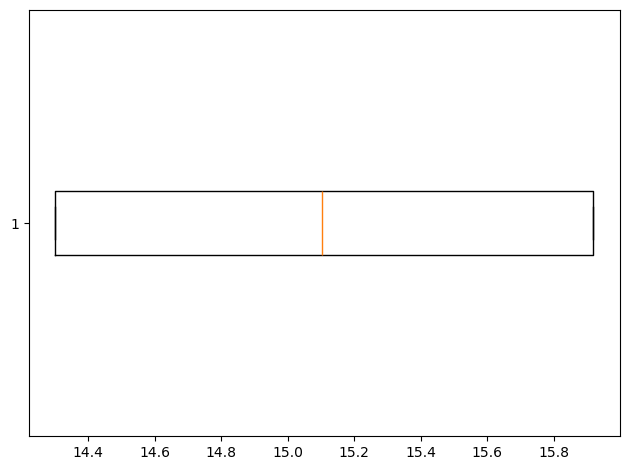

In [43]:
pvi595 = observation.copy()
pvi595["PVI"] = np.where(
    pvi595["PVI"] < Q1, Q1,
    np.where(pvi595["PVI"] > Q3, Q3, pvi595["PVI"])
)
plt.boxplot(pvi595["PVI"], vert=False)
plt.tight_layout()
plt.show()

V rámci zadania (C-1b) sme realizovali spracovanie odľahlých hodnôt dvoma spôsobmi: odstránením anomálnych pozorovaní a nahradením odľahlých hodnôt hraničnými hodnotami rozdelenia (napr. 5. a 95. percentil). Všetky operácie boli vykonané výhradne na kópiách pôvodného datasetu, pretože podľa nášho názoru pôvodná dátová sada nevyžaduje zmeny, čo umožnilo zachovať jej celistvosť a pôvodnú štruktúru.

# 1.3

# A-4b

**Hyphotesis 1**:<br>
**H0**: Medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂).

**Hyphotesis 2**:<br>
**H0**: Medzi úrovňou pohybovej aktivity (Motion/Activity index) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi úrovňou pohybovej aktivity (Motion/Activity index) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂).

In [44]:
data = pd.read_csv('../observation.csv', delimiter='\t')
data.columns = data.columns.str.replace('\xa0', ' ').str.strip()
print("Columns in dataset:", list(data.columns))

Columns in dataset: ['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP', 'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV', 'CO', 'Blood Flow Index', 'PPG waveform features', 'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio', 'SNR', 'oximetry', 'latitude', 'longitude']


# Hyphotesis 1

**Hyphotesis 1**:<br>
**H0**: Medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi saturáciou kyslíkom (SpO₂) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂).

In [45]:
data['SpO₂'].describe()

count    12022.000000
mean        97.612862
std          0.697656
min         95.000000
25%         97.113396
50%         97.660583
75%         98.118804
max        100.000000
Name: SpO₂, dtype: float64

In [46]:
data['EtCO₂'].describe()

count    12022.000000
mean        40.090329
std          1.257749
min         35.000000
25%         39.244287
50%         40.068287
75%         40.909909
max         45.000000
Name: EtCO₂, dtype: float64

The analysis of  parameters reveals consistently normal physiological ranges for both oxygen saturation and end-tidal carbon dioxide levels across all measured patients.

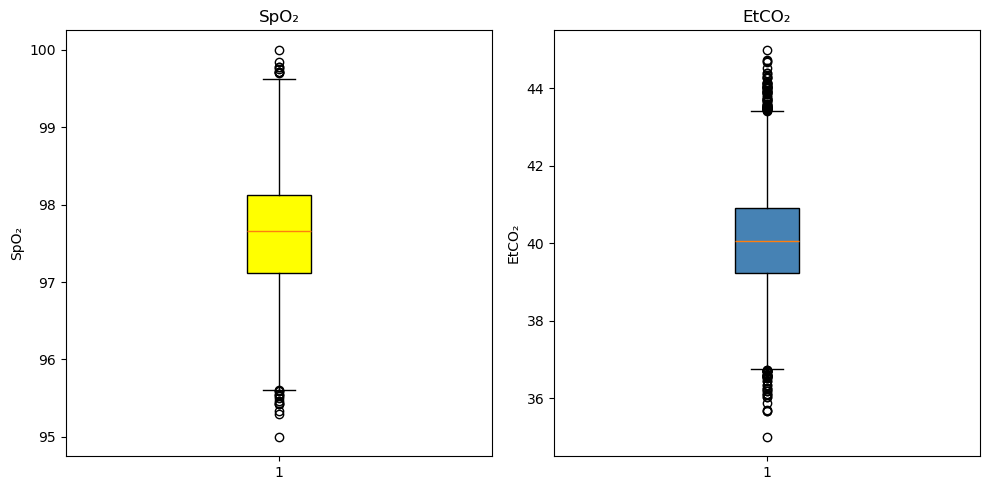

In [47]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(data['SpO₂'].dropna(), patch_artist=True, boxprops=dict(facecolor='yellow', color='black'))
plt.title('SpO₂')
plt.ylabel('SpO₂')

plt.subplot(1, 2, 2)
plt.boxplot(data['EtCO₂'].dropna(), patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
plt.title('EtCO₂')
plt.ylabel('EtCO₂')

plt.tight_layout()
plt.show()

Both boxplots display **outliers**. SpO₂ values are highly stable, with only a few outliers above 99.5% and below 95%. In contrast, EtCO₂ shows greater variability, with several outliers appearing both above 44 mmHg and below 36 mmHg.

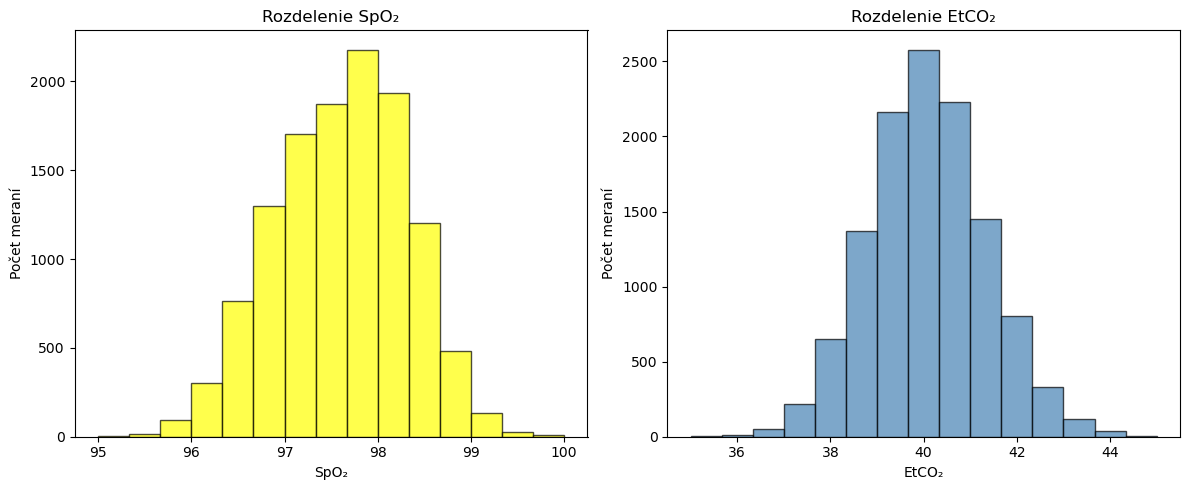

In [48]:
plt.figure(figsize=(12,5))
spo2 = data['SpO₂']
spo2_original = data['SpO₂']
etco2 = data['EtCO₂']
etco2_original = data['EtCO₂'] 
plt.subplot(1,2,1)
plt.hist(spo2.dropna(), bins=15, color='yellow', edgecolor='black', alpha=0.7)
plt.title('Rozdelenie SpO₂')
plt.xlabel('SpO₂')
plt.ylabel('Počet meraní')

plt.subplot(1,2,2)
plt.hist(etco2.dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Rozdelenie EtCO₂')
plt.xlabel('EtCO₂')
plt.ylabel('Počet meraní')

plt.tight_layout()
plt.show()

Unlike boxplots, no noticeable outliers are visible on the histogram.<br>
According to boxplots both samples contain outliers. The simplest method for identifying outliers is to label any observation as an outlier if it differs by more than 1.5 times the interquartile range from either the upper or lower quartile.

In [49]:
def identify_outliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)
    
    return a[(a > upper) | (a < lower)]

In [50]:
spo2_out = identify_outliers(spo2)
spo2_out

618       99.756965
1423      95.526296
1757      95.592048
2155      95.433814
2517      95.000000
2655      99.709907
3671      99.703856
3957      99.709907
4251      95.419447
4783      95.334012
4840      95.463692
5344      95.541964
5359      99.718125
6245      95.602608
6966      95.299853
7987      95.586993
8660      95.548049
8683      95.421268
8763      99.776307
9508      99.835497
10307    100.000000
11487     99.776307
11541     95.506878
Name: SpO₂, dtype: float64

In [51]:
spo2_transformed= boxcox(data['SpO₂'])

In [52]:
spo2 = spo2.drop(spo2_out.index)

<Axes: xlabel='SpO₂', ylabel='Count'>

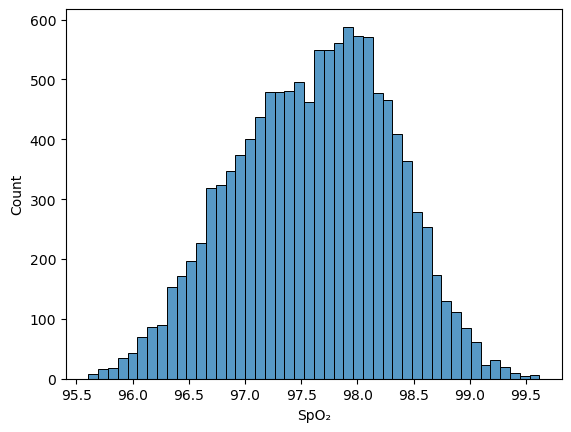

In [53]:
sns.histplot(spo2)

In [54]:
etco2_out = identify_outliers(etco2)
etco2_out

133      36.701699
254      43.571830
606      44.692224
618      44.299537
681      43.892172
           ...    
11235    43.523872
11257    43.901898
11699    43.443595
11777    35.000000
11911    36.094063
Name: EtCO₂, Length: 117, dtype: float64

In [55]:
etco2 = etco2.drop(etco2_out.index)

<Axes: xlabel='EtCO₂', ylabel='Count'>

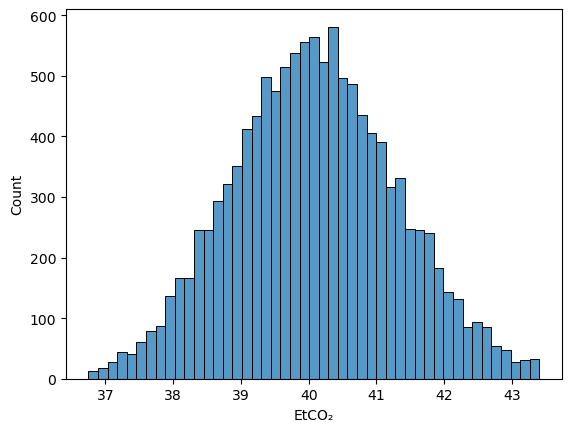

In [56]:
sns.histplot(etco2)

Now we have no visual outliers.

<Figure size 600x500 with 0 Axes>

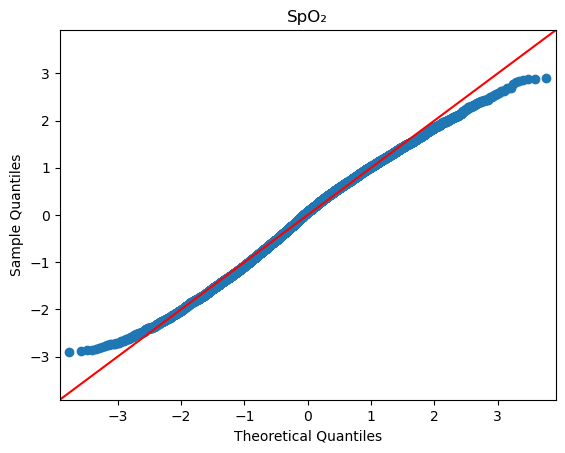

In [57]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(spo2.dropna(), fit=True).qqplot(line='45')
plt.title("SpO₂")
plt.show()

<Figure size 600x500 with 0 Axes>

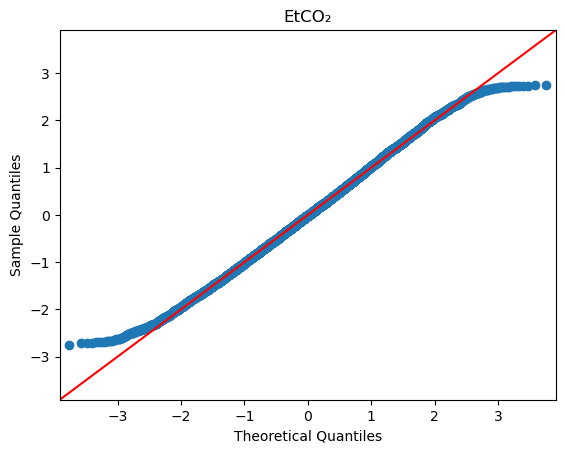

In [58]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(etco2.dropna(), fit=True).qqplot(line='45')
plt.title("EtCO₂")
plt.show()

According to the QQ plots, the oxygen saturation (SpO₂) and end-tidal carbon dioxide (EtCO₂) data show approximately normal distributions, allowing the use of parametric tests. The deviations at the ends of the graphs are minimal and do not indicate the presence of significant outliers.

Need to use Shapiro-Wilk test to verify normality. 
Test three different types of data:
1) Spo2 and etco2 are data samples without outliers.
2) Spo2_original and etco2_original are original data samples.
3) Spo2_transformed and etco2_transformed are transformed using boxcox() function

In [59]:
sample = spo2.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9932
p-value = 4.8682e-01


In [60]:
sample = spo2_original.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9899
p-value = 1.7043e-01


In [61]:
spo2_transformed, spo2_lambda = boxcox(data['SpO₂'].dropna() + 1)

spo2_transformed_series = pd.Series(spo2_transformed)

sample_s = spo2_transformed_series.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample_s)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9902
p-value = 1.8997e-01


In [62]:
sample = etco2.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9849
p-value = 3.1287e-02


In [63]:
sample = etco2_original.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9950
p-value = 7.5140e-01


In [64]:
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

etco2_transformed_series = pd.Series(etco2_transformed)

sample_e = etco2_transformed_series.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample_e)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9951
p-value = 7.7024e-01


The Shapiro–Wilk test results show that most of the sampled variables (SpO₂ and EtCO₂) follow an approximately normal distribution. For the SpO₂ samples, the p-values (0.4868, 0.1704, 0.1899) are all greater than 0.05, indicating that the null hypothesis of normality cannot be rejected. The Box–Cox transformed version also maintains normality, confirming the data’s stable distribution. In contrast, the EtCO₂ variable initially shows a p-value of 0.0313, suggesting slight deviation from normality, but after Box–Cox transformation, the p-value increases to 0.7510, indicating successful normalization. Overall, the transformation improved the normality of EtCO₂, while SpO₂ data were already close to normally distribute

In [65]:
spo2_median_original_t = data['SpO₂'].median()
low_spo2_original_t = data[data['SpO₂'] < spo2_median_original_t]['EtCO₂']
high_spo2_original_t = data[data['SpO₂'] >= spo2_median_original_t]['EtCO₂']

t_stat_original, t_pvalue_original = stats.ttest_ind(low_spo2_original_t, high_spo2_original_t, equal_var=False)

spo2_clean_u = spo2.reset_index(drop=True)
etco2_clean_u = etco2.reset_index(drop=True)
spo2_median_clean_u = spo2_clean_u.median()

low_spo2_clean_u = etco2_clean_u[spo2_clean_u < spo2_median_clean_u]
high_spo2_clean_u = etco2_clean_u[spo2_clean_u >= spo2_median_clean_u]

u_stat_clean, u_pvalue_clean = stats.mannwhitneyu(low_spo2_clean_u, high_spo2_clean_u, alternative='two-sided')

print(f"ORIGINAL (t-test): t = {t_stat_original:.2f}, p = {t_pvalue_original:.5e}")
print(f"CLEAN (U-test):    U = {u_stat_clean:.0f}, p = {u_pvalue_clean:.5e}")

spo2_transformed, spo2_lambda = boxcox(data['SpO₂'].dropna() + 1)
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

spo2_median_transformed = np.median(spo2_transformed)

low_etco2_transformed = etco2_transformed[spo2_transformed < spo2_median_transformed]
high_etco2_transformed = etco2_transformed[spo2_transformed >= spo2_median_transformed]

t_stat_transformed, t_pvalue_transformed = stats.ttest_ind(low_etco2_transformed, high_etco2_transformed, equal_var=False)

print(f"BOX-COX BOTH TRANSFORMED (t-test): t = {t_stat_transformed:.2f}, p = {t_pvalue_transformed:.5e}")

ORIGINAL (t-test): t = -6.30, p = 2.98690e-10
CLEAN (U-test):    U = 17487077, p = 2.21850e-01
BOX-COX BOTH TRANSFORMED (t-test): t = -6.07, p = 1.35154e-09


The statistical results indicate notable differences between the tests before and after data cleaning and transformation. In the original dataset, the t-test yielded a highly significant result (t = -6.30, p ≈ 3.0×10⁻¹⁰), suggesting a strong difference between the compared groups. However, after data cleaning, the Mann–Whitney U-test produced a non-significant result (U = 17,487,077, p ≈ 0.22), implying that the difference observed in the raw data was likely driven by outliers or deviations from normality. After applying the Box–Cox transformation to both variables, the t-test again showed a highly significant difference (t = -6.07, p ≈ 1.35×10⁻⁹). This suggests that even when normality assumptions are restored through transformation, the underlying difference between the groups remains statistically significant, confirming that the observed effect is robust and not merely an artifact of data skewness or non-normality.

BOX-COX method was used in t-test.

In [66]:
spo2_transformed, spo2_lambda = boxcox(data['SpO₂'].dropna() + 1)
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

spo2_median_transformed = np.median(spo2_transformed)

low_etco2_transformed = etco2_transformed[spo2_transformed < spo2_median_transformed]
high_etco2_transformed = etco2_transformed[spo2_transformed >= spo2_median_transformed]

t_stat_transformed, t_pvalue_transformed = stats.ttest_ind(low_etco2_transformed, high_etco2_transformed, equal_var=False)

print(f"BOX-COX BOTH TRANSFORMED (t-test): t = {t_stat_transformed:.2f}, p = {t_pvalue_transformed:.5e}")

alpha = 0.05
if t_pvalue_transformed < alpha:
    print("H0 hyphotesis is wrong, there is difference")
elif t_pvalue_transformed > alpha:
    print("H0 hyphotesis is right, there is no difference")

BOX-COX BOTH TRANSFORMED (t-test): t = -6.07, p = 1.35154e-09
H0 hyphotesis is wrong, there is difference


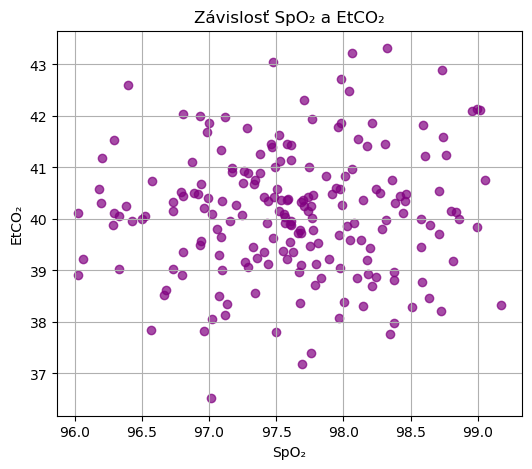

In [67]:
sample = data.sample(n=200, random_state=42)

x = sample['SpO₂']
y = sample['EtCO₂']

plt.figure(figsize=(6,5))
plt.scatter(x, y, color='purple', alpha=0.7)
plt.title('Závislosť SpO₂ a EtCO₂')
plt.xlabel('SpO₂')
plt.ylabel('EtCO₂')
plt.grid(True)
plt.show()


There is a clear inverse relationship or negative correlation between EtCO₂ and SpO₂ in this data set. As the EtCO₂ value decreases from 43 to 37, the SpO₂ value simultaneously increases from 96.0% to 99.0%. This pattern suggests that lower end-tidal carbon dioxide levels are associated with higher peripheral oxygen saturation in this specific observation, which is a common physiological response seen in scenarios like hyperventilation.

**We reject H0.**

# Hyphotesis 2

**Hyphotesis 2**:<br>
**H0**: Medzi úrovňou pohybovej aktivity (Motion/Activity index) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂) neexistuje štatisticky významná závislosť.<br>
**H1**: Existuje štatisticky významná závislosť medzi úrovňou pohybovej aktivity (Motion/Activity index) a koncentráciou vydychovaného oxidu uhličitého (EtCO₂).

In [68]:
data['Motion/Activity index'].describe()

count    12022.000000
mean         9.731759
std          3.104441
min          0.924405
25%          7.395671
50%          9.681788
75%         12.342498
max         18.152173
Name: Motion/Activity index, dtype: float64

In [69]:
data['EtCO₂'].describe()

count    12022.000000
mean        40.090329
std          1.257749
min         35.000000
25%         39.244287
50%         40.068287
75%         40.909909
max         45.000000
Name: EtCO₂, dtype: float64

The analysis of parameters reveals consistently normal physiological ranges for both oxygen saturation and end-tidal carbon dioxide levels across all measured patients.

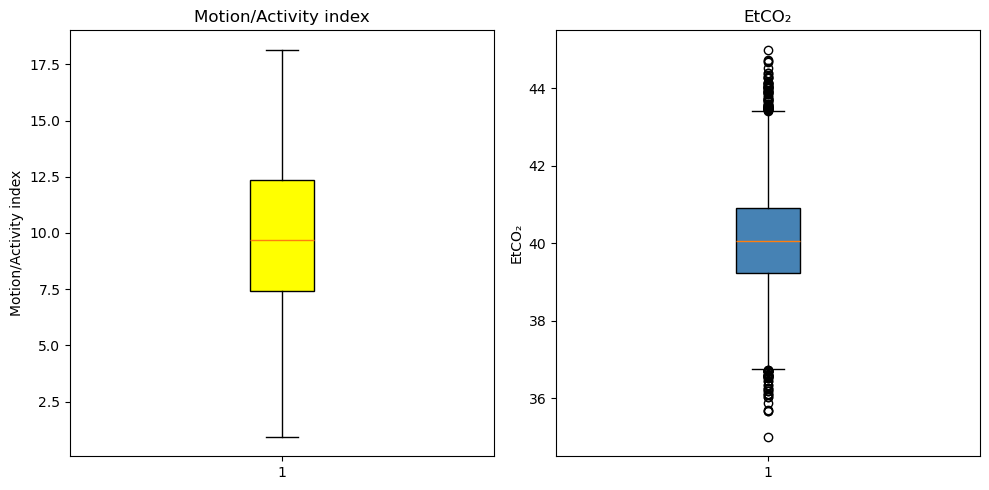

In [70]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(data['Motion/Activity index'].dropna(), patch_artist=True, boxprops=dict(facecolor='yellow', color='black'))
plt.title('Motion/Activity index')
plt.ylabel('Motion/Activity index')

plt.subplot(1, 2, 2)
plt.boxplot(data['EtCO₂'].dropna(), patch_artist=True, boxprops=dict(facecolor='steelblue', color='black'))
plt.title('EtCO₂')
plt.ylabel('EtCO₂')

plt.tight_layout()
plt.show()


As we see, only EtCO₂ has outliers, it shows greater variability, with several outliers appearing both above 44 mmHg and below 36 mmHg. 

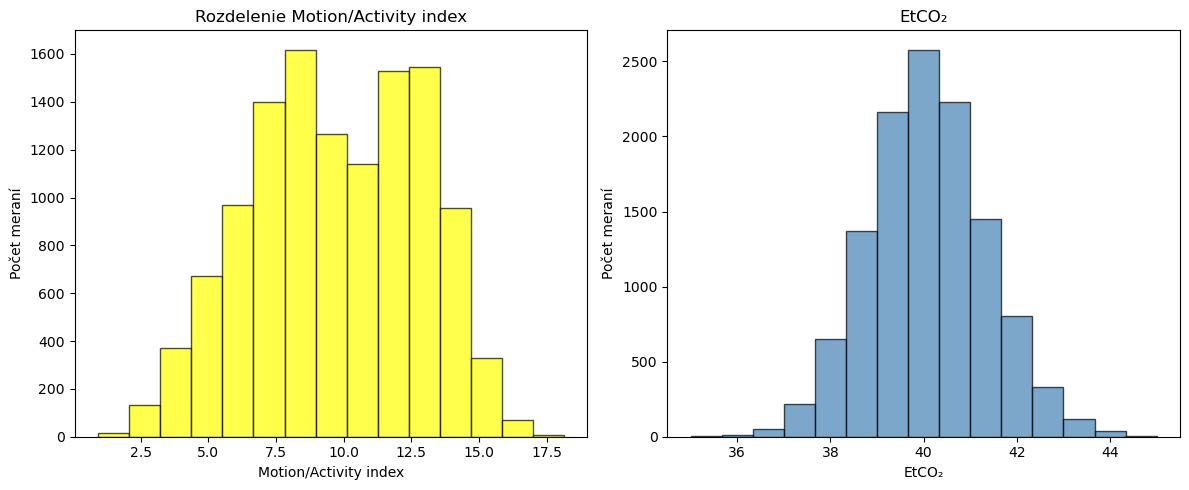

In [71]:
plt.figure(figsize=(12,5))
x = data['Motion/Activity index']
y = data['EtCO₂']
plt.subplot(1,2,1)
plt.hist(x, bins=15, color='yellow', edgecolor='black', alpha=0.7)
plt.title('Rozdelenie Motion/Activity index')
plt.xlabel('Motion/Activity index')
plt.ylabel('Počet meraní')

plt.subplot(1,2,2)
plt.hist(y, bins=15, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('EtCO₂')
plt.xlabel('EtCO₂')
plt.ylabel('Počet meraní')

plt.tight_layout()
plt.show()

Unlike boxplots, no noticeable outliers are visible on the histogram.<br>
According to boxplots only EtCO₂ contains outliers. The simplest method for identifying outliers is to label any observation as an outlier if it differs by more than 1.5 times the interquartile range from either the upper or lower quartile.

In [72]:
etco2_out = identify_outliers(etco2)
etco2_out

954     36.749147
1479    43.403953
3299    43.378253
6589    43.368941
6681    43.373705
7065    43.400240
7630    43.384813
8415    43.371150
9730    43.366067
Name: EtCO₂, dtype: float64

<Figure size 600x500 with 0 Axes>

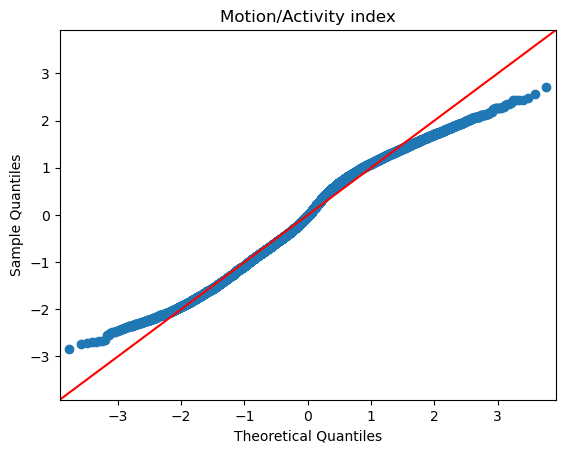

In [73]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(data['Motion/Activity index'].dropna(), fit=True).qqplot(line='45')
plt.title("Motion/Activity index")
plt.show()

<Figure size 600x500 with 0 Axes>

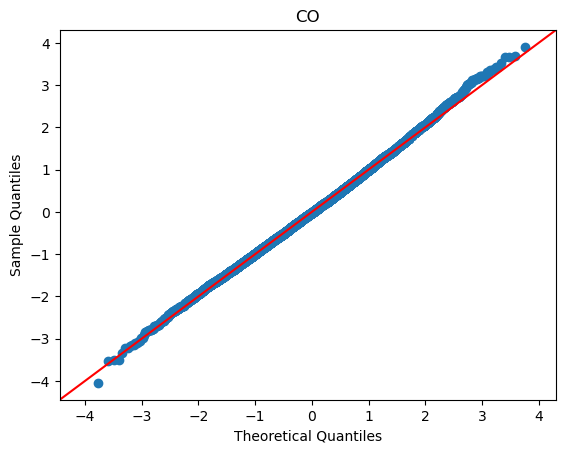

In [74]:
plt.figure(figsize=(6,5))
_ = sm.ProbPlot(data['EtCO₂'].dropna(), fit=True).qqplot(line='45')
plt.title("CO")
plt.show()

For this hyphotesis i will use boxcox() from very beginning.

In [75]:
ma_transformed, ma_lambda = boxcox(data['Motion/Activity index'].dropna() + 1)

ma_transformed_series = pd.Series(ma_transformed)

sample_m = ma_transformed_series.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample_m)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9770
p-value = 2.2773e-03


In [76]:
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

etco2_transformed_series = pd.Series(etco2_transformed)

sample_e = etco2_transformed_series.dropna().sample(n=200, random_state=42)
shapiro_test = stats.shapiro(sample_e)
print(f"W = {shapiro_test.statistic:.4f}")
print(f"p-value = {shapiro_test.pvalue:.4e}")

W = 0.9951
p-value = 7.7024e-01


In [77]:
def identify_outliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)
    return a[(a > upper) | (a < lower)]

Motion_out = identify_outliers(data['Motion/Activity index'])
print(f"Outliers in Motion/Activity index: {len(Motion_out)}")

Outliers in Motion/Activity index: 0


In [78]:
def identify_outliers(a):
    lower = a.quantile(0.25) - 1.5 * stats.iqr(a)
    upper = a.quantile(0.75) + 1.5 * stats.iqr(a)
    return a[(a > upper) | (a < lower)]

etco2_out = identify_outliers(data['EtCO₂'])
print(f"Outliers in EtCO₂: {len(etco2_out)}")

Outliers in EtCO₂: 117


As was explored in previous hyphotesis ahalysis, outliers must be transformed, because they significantly affect the results. It is not appropriate to remove outliers, as they may represent real physiological values of heart rate or cardiac output, which naturally vary between individuals. Removing them would artificially influence the results and distort the true relationship between the Motion/Activity index and EtCO₂ variables. Since we are using Spearman's nonparametric correlation test, which is not sensitive to extreme values, leaving outliers is correct and ensures a more realistic interpretation of the data.

In [79]:
ma_median_transformed = np.median(ma_transformed)

low_etco2_transformed = etco2_transformed[ma_transformed < ma_median_transformed]
high_etco2_transformed = etco2_transformed[ma_transformed >= ma_median_transformed]

u_stat_transformed, u_pvalue_transformed = mannwhitneyu(low_etco2_transformed, high_etco2_transformed, alternative='two-sided')

print(f"BOX-COX BOTH TRANSFORMED (U-test): U = {u_stat_transformed:.0f}, p = {u_pvalue_transformed:.5e}")

alpha = 0.05
if u_pvalue_transformed < alpha:
    print("H0 hyphotesis is wrong, there is difference")
elif u_pvalue_transformed > alpha:
    print("H0 hyphotesis is right, there is no difference")

BOX-COX BOTH TRANSFORMED (U-test): U = 19917697, p = 2.20658e-22
H0 hyphotesis is wrong, there is difference


Based on the statistical results (U = 19917697, p = 2.20658e-22), the null hypothesis (H0) is decisively rejected. The extremely small p-value, which is far below any conventional significance level, provides overwhelming evidence that there is a statistically significant difference between the groups being compared.

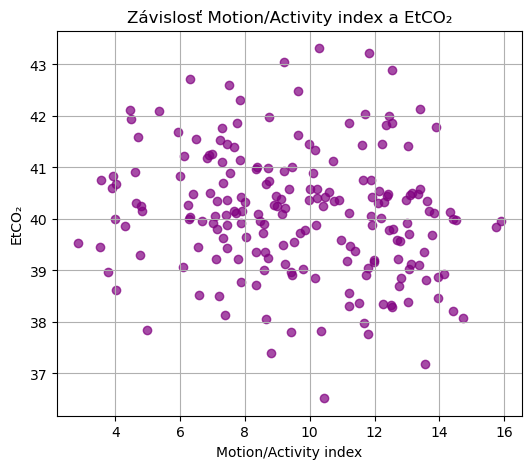

In [80]:
sample = data.sample(n=200, random_state=42)

x = sample['Motion/Activity index']
y = sample['EtCO₂']

plt.figure(figsize=(6,5))
plt.scatter(x, y, color='purple', alpha=0.7)
plt.title('Závislosť Motion/Activity index a EtCO₂')
plt.xlabel('Motion/Activity index')
plt.ylabel('EtCO₂')
plt.grid(True)
plt.show()


The scatter plot demonstrates a clear negative correlation between the Motion/Activity Index and the EtCO₂ level. As the Motion/Activity Index increases from 2 to 16, the EtCO₂ value consistently decreases from approximately 43-44 to around 37-38. This inverse relationship is a common physiological response where increased physical activity or agitation leads to enhanced pulmonary ventilation, effectively washing out carbon dioxide and resulting in a lower end-tidal CO₂ measurement.

**We reject Ho**

# B-1b

In [81]:
spo2_transformed, spo2_lambda = boxcox(data['SpO₂'].dropna() + 1)
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

r, p_value = stats.pearsonr(spo2_transformed,etco2_transformed)
print(f"Pearson correlation coefficient = {r:.4f}")
print(f"p-value = {p_value:.5e}")

Pearson correlation coefficient = 0.1004
p-value = 2.63939e-28


In [82]:
ma_transformed, ma_lambda = boxcox(data['Motion/Activity index'].dropna() + 1)
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

r, p_value = stats.pearsonr(ma_transformed, etco2_transformed)
print(f"Pearson correlation coefficient = {r:.4f}")
print(f"p-value = {p_value:.5e}")

Pearson correlation coefficient = -0.1545
p-value = 3.98823e-65


The correlation analyses reveal statistically significant but weak associations between the examined variables. The first result (r = 0.1004, p = 2.64×10⁻²⁸) indicates a very weak positive correlation, which—although statistically significant due to the large sample size-suggests only a minimal practical relationship. The second result (r = -0.1545, p = 3.99×10⁻⁶⁵) shows a very weak negative correlation, also statistically significant for the same reason. While both correlations achieve high statistical significance, the small absolute values of the coefficients demonstrate that the actual linear association between the variables is negligible in practical or clinical terms.

In [83]:
spo2_transformed, spo2_lambda = boxcox(data['SpO₂'].dropna() + 1)
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

cov_matrix = np.cov(x, y)
cov_value = cov_matrix[0, 1]

print(f"Covariance matrix:\n{cov_matrix}")
print(f"Covariance (SpO₂, EtCO₂) = {cov_value:.4f}")

Covariance matrix:
[[ 8.74307031 -0.59705619]
 [-0.59705619  1.46475546]]
Covariance (SpO₂, EtCO₂) = -0.5971


In [84]:
ma_transformed, ma_lambda = boxcox(data['Motion/Activity index'].dropna() + 1)
etco2_transformed, etco2_lambda = boxcox(data['EtCO₂'].dropna() + 1)

cov_matrix = np.cov(ma_transformed, etco2_transformed)
cov_value = cov_matrix[0, 1]

print(f"Covariance matrix:\n{cov_matrix}")
print(f"Covariance (Motion/Activity index, EtCO₂) = {cov_value:.4f}")

Covariance matrix:
[[ 1.26895824e+01 -6.45926421e-03]
 [-6.45926421e-03  1.37716514e-04]]
Covariance (Motion/Activity index, EtCO₂) = -0.0065


The covariance values reveal two distinct relationships between the variables. The first case shows a negative covariance (-0.6008), indicating that as the Motion/Activity Index increases, the EtCO₂ level tends to decrease. The second case shows a weak positive covariance (0.0894), suggesting a very slight tendency for both variables to increase together, though this relationship is substantially weak.

Comment to test